[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\rraka\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rraka\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Lowercase Text:
the cricket team secured a thrilling victory in the final match of the tournament football players are training hard for the upcoming international championship the tennis champion won her third consecutive grand slam title cricket remains one of the most popular sports with millions of fans worldwide

Tokens after Stopword Removal:
['cricket', 'team', 'secured', 'thrilling', 'victory', 'final', 'match', 'tournament', 'football', 'players', 'training', 'hard', 'upcoming', 'international', 'championship', 'tennis', 'champion', 'third', 'consecutive', 'grand', 'slam', 'title', 'cricket', 'remains', 'one', 'popular', 'sports', 'millions', 'fans', 'worldwide']

Word Frequency Distribution:
cricket : 2
team : 1
secured : 1
thrilling : 1
victory : 1
final : 1
match : 1
tournament : 1
football : 1
players : 1
training : 1
hard : 1
upcoming : 1
international : 1
championship : 1
tennis : 1
champion : 1
third : 1
consecutive : 1
grand : 1
slam : 1
title : 1
remains : 1
one : 1
p

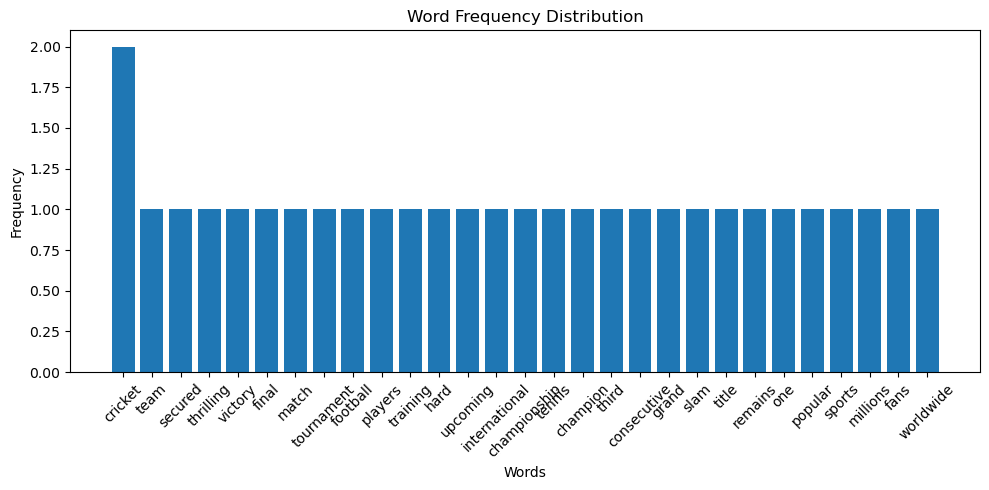

In [1]:
import nltk
import string
from collections import Counter
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# Download required resources
nltk.download('punkt')
nltk.download('stopwords')

# Sample News Articles
articles = [
    "Artificial intelligence is transforming healthcare and education systems",
    "AI and machine learning are the future of technology and innovation",
    "Healthcare systems are improving with artificial intelligence solutions",
    "Education technology is growing rapidly with AI based tools"
]

# 1. Convert all text to lowercase
text = " ".join(articles).lower()

print("Lowercase Text:")
print(text)

# 2. Remove punctuation
text = text.translate(str.maketrans('', '', string.punctuation))

# 3. Tokenization
tokens = word_tokenize(text)

# Stopwords Removal
stop_words = set(stopwords.words('english'))
filtered_tokens = [word for word in tokens if word not in stop_words]
print("\nTokens after Stopword Removal:")
print(filtered_tokens)

# 4. Compute Word Frequency Distribution
word_freq = Counter(filtered_tokens)
print("\nWord Frequency Distribution:")
for word, freq in word_freq.items():
    print(word, ":", freq)

# 5. Build Vocabulary (Unique Words Set)
vocabulary = set(filtered_tokens)
print("\nVocabulary (Unique Words):")
print(vocabulary)
print("\nVocabulary Size:", len(vocabulary))

# 6. Identify Top 5 Most Frequent Words
top5 = word_freq.most_common(5)
print("\nTop 5 Most Frequent Words:")
for word, freq in top5:
    print(word, ":", freq)
    
# 7. Calculate Type-Token Ratio (TTR)
total_tokens = len(filtered_tokens)
unique_tokens = len(vocabulary)
ttr = unique_tokens / total_tokens
print("\nTotal Tokens:", total_tokens)
print("Unique Tokens:", unique_tokens)
print("Type-Token Ratio (TTR):", round(ttr, 2))

# 8. Analyze Dominant Topic
topics = {
    "Artificial Intelligence": ["artificial", "intelligence", "ai"],
    "Healthcare": ["healthcare"],
    "Education": ["education"],
    "Technology": ["technology", "machine", "learning", "innovation", "tools"]
}
topic_scores = {}
for topic, keywords in topics.items():
    score = sum(word_freq[word] for word in keywords if word in word_freq)
    topic_scores[topic] = score
print("\nTopic Scores:")
for topic, score in topic_scores.items():
    print(topic, ":", score)
dominant_topic = max(topic_scores, key=topic_scores.get)
print("\nDominant Topic:", dominant_topic)

# 9. Visualize Word Frequency Using Bar Chart
words = list(word_freq.keys())
frequencies = list(word_freq.values())

plt.figure(figsize=(10, 5))
plt.bar(words, frequencies)
plt.title("Word Frequency Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()